<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
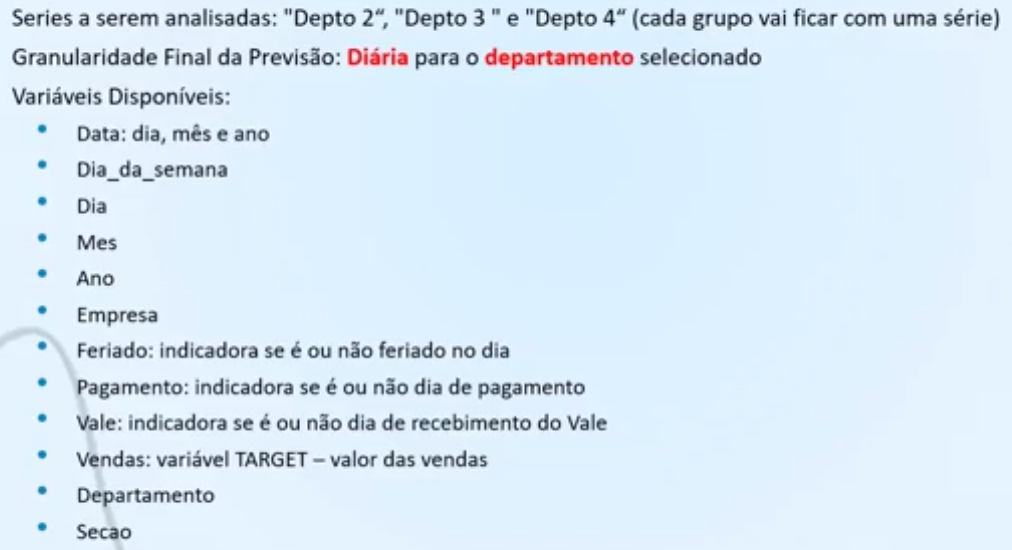

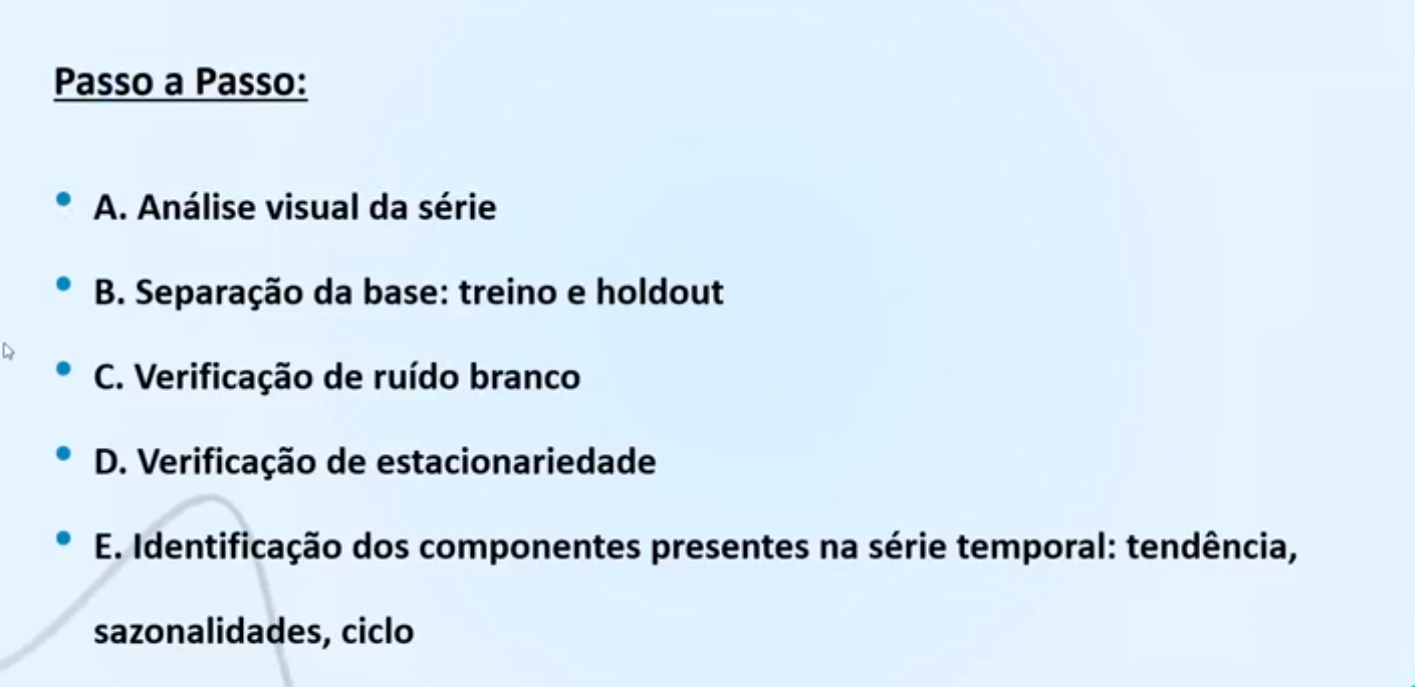

BIBLIOTECAS

In [49]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import (SimpleExpSmoothing,ExponentialSmoothing,Holt)
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

import dateutil
import calendar

import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from math import sqrt

print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


1. CARREGAR DADOS

In [2]:
!pip install gdown # ponte entre Google Drive e Python

In [3]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 141MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [4]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [5]:
# ver formato que está a data

data = data.drop(columns=['Data_new'])
data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [6]:
data['Data'] = pd.to_datetime(data['Data'])

/tmp/ipykernel_4449/3475004564.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Data'] = pd.to_datetime(data['Data'])


In [7]:
data['Data'].head()
data['Data'].dtype

dtype('<M8[ns]')

In [8]:
data['Data_BR'] = data['Data'].dt.strftime('%d/%m/%Y')

data['Data_BR'] = pd.to_datetime(
    data['Data_BR'],
    format='%d/%m/%Y'
)

In [9]:
data['Data_BR'].dtype

dtype('<M8[ns]')

In [10]:
# Data no formato brasileiro e como data:

data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção,Data_BR
0,2018-01-02,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1,2018-01-02
1,2018-01-02,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2,2018-01-02
2,2018-01-02,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3,2018-01-02
3,2018-01-02,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4,2018-01-02
4,2018-01-02,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7,2018-01-02
5,2018-01-02,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26,2018-01-02
6,2018-01-02,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5,2018-01-02
7,2018-01-02,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6,2018-01-02
8,2018-01-02,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7,2018-01-02
9,2018-01-02,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8,2018-01-02


2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS

Método de acumulação - soma

Intervalo de tempo - diária

In [11]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [12]:
data_depto4 = data[data['Departamento'] == 'Depto 4'].copy()

vendas_dia = (
    data_depto4.groupby(['Data_BR'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)


        Data_BR      Vendas
0    2018-01-02  1812134.19
1    2018-01-03  1622115.60
2    2018-01-04  1486888.42
3    2018-01-05  2015469.36
4    2018-01-06  2678387.64
...         ...         ...
1143 2021-02-24  2025751.85
1144 2021-02-25  2216224.47
1145 2021-02-26  3098829.40
1146 2021-02-27  4592539.97
1147 2021-02-28  2157356.38

[1148 rows x 2 columns]


In [13]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [14]:
vendas_dia['Ano'] = vendas_dia['Data_BR'].dt.year

vendas_dia.head(10)

,Data_BR,Vendas,Ano
0,2018-01-02,1812134.19,2018
1,2018-01-03,1622115.60,2018
2,2018-01-04,1486888.42,2018
3,2018-01-05,2015469.36,2018
4,2018-01-06,2678387.64,2018
5,2018-01-07,1120660.99,2018
6,2018-01-08,1600882.79,2018
7,2018-01-09,1963629.68,2018
8,2018-01-10,1667902.81,2018
9,2018-01-11,1457775.73,2018


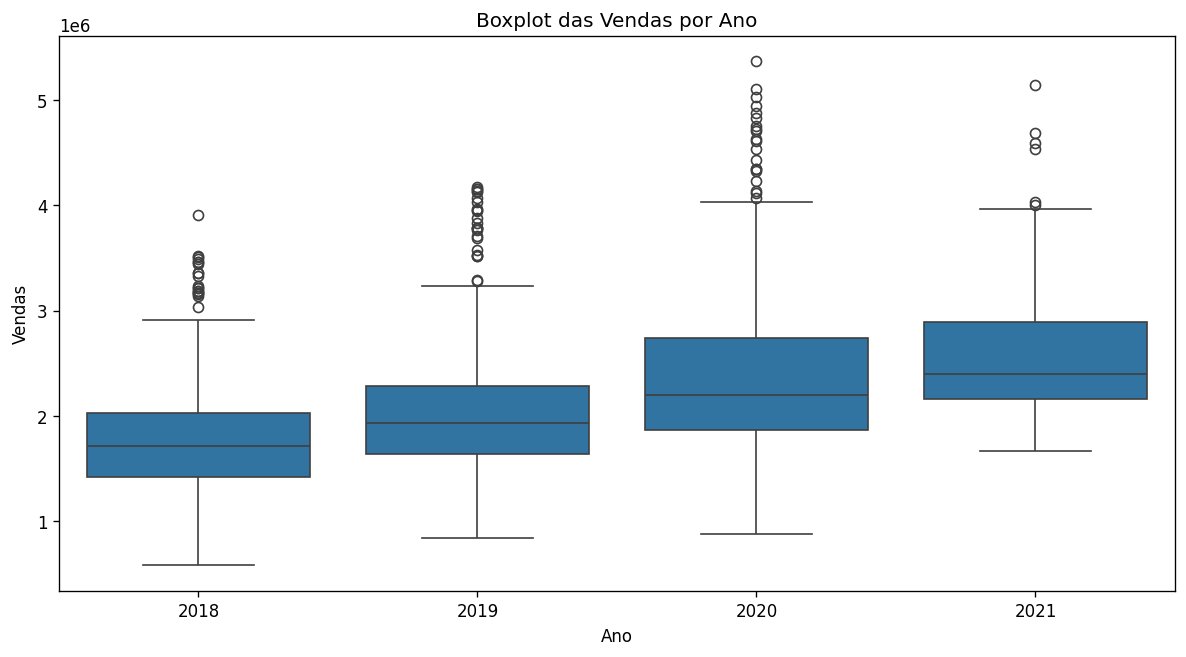

In [15]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [16]:
vendas_dia.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


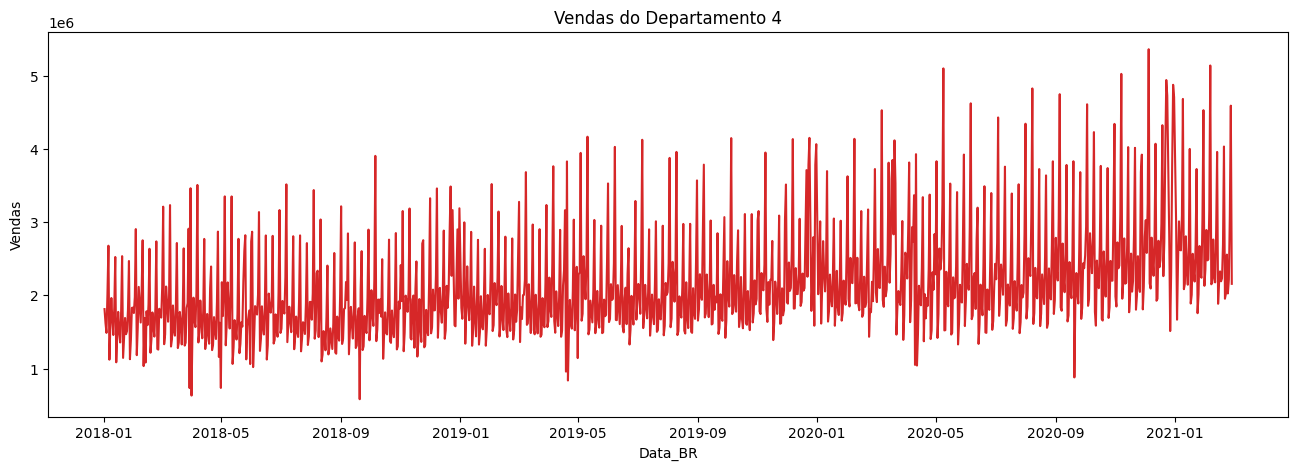

In [17]:
# Visualizando a série temporal

def plot_df(vendas_dia, x, y, title="", xlabel='Data_BR', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia=vendas_dia,
    x=vendas_dia['Data_BR'],
    y=vendas_dia['Vendas'],
    title='Vendas do Departamento 4'
)

In [18]:
print(vendas_dia['Vendas'].isna().sum())
print(vendas_dia.shape)
print(vendas_dia.info())

0
(1148, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1148 entries, 0 to 1147
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Data_BR  1148 non-null   datetime64[ns]
 1   Vendas   1148 non-null   float64       
 2   Ano      1148 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 22.6 KB
None


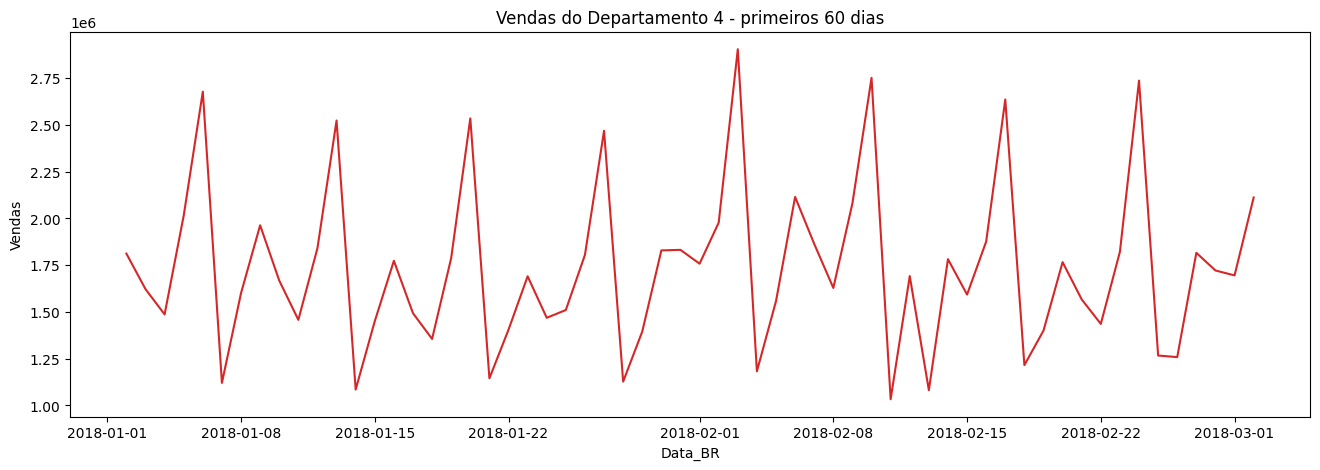

In [19]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia = vendas_dia.sort_values('Data_BR')

trecho = vendas_dia.iloc[:60]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

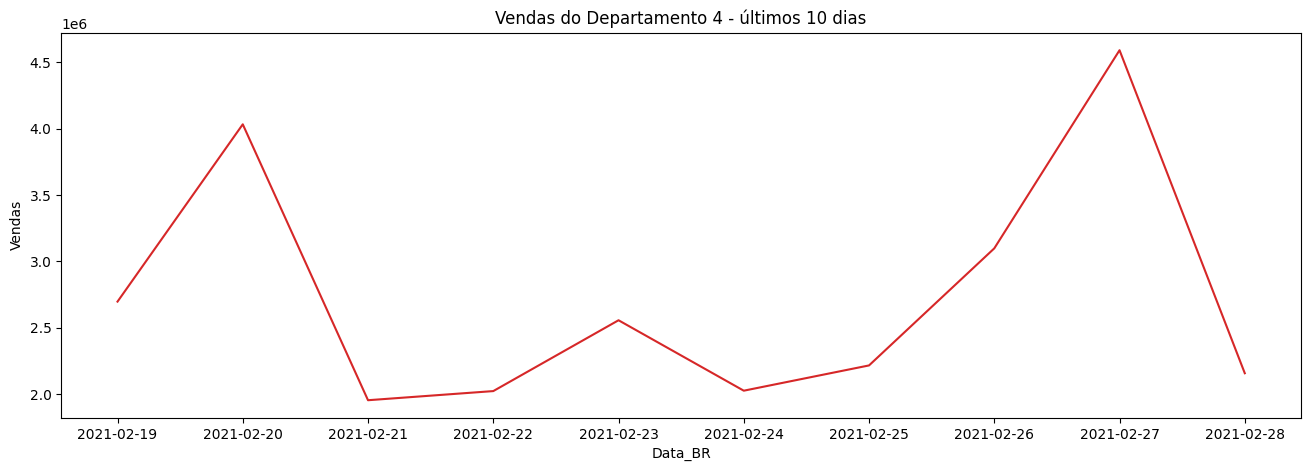

In [20]:
trecho = vendas_dia.iloc[-10:]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - últimos 10 dias'
)

In [21]:
# Tem dias faltantes?
datas_completas = pd.date_range(
    start=vendas_dia['Data_BR'].min(),
    end=vendas_dia['Data_BR'].max(),
    freq='D'
)

faltantes = datas_completas.difference(vendas_dia['Data_BR'])

print(faltantes)
print('Quantidade de dias faltantes:', len(faltantes))

DatetimeIndex(['2018-12-25', '2019-01-01', '2019-12-25', '2020-01-01',
               '2020-12-25', '2021-01-01'],
              dtype='datetime64[ns]', freq=None)
Quantidade de dias faltantes: 6


In [22]:
# Imputar dias faltantes pela média do dia da semana no mes/ano

# Garantir formato datetime
vendas_dia['Data_BR'] = pd.to_datetime(vendas_dia['Data_BR'])

# Criar calendário completo
datas = pd.date_range(
    vendas_dia['Data_BR'].min(),
    vendas_dia['Data_BR'].max(),
    freq='D'
)

# Inserir datas faltantes
serie = (
    vendas_dia
    .set_index('Data_BR')
    .reindex(datas)
    .rename_axis('Data_BR')
    .reset_index()
)

# Variáveis auxiliares
serie['Ano'] = serie['Data_BR'].dt.year
serie['Mes'] = serie['Data_BR'].dt.month
serie['DiaSemana'] = serie['Data_BR'].dt.dayofweek

# Marcar observações originalmente faltantes
serie['Imputado'] = serie['Vendas'].isna()

# Média do mesmo dia da semana dentro do mesmo mês/ano
serie['Media_DS'] = (
    serie
    .groupby(['Ano','Mes','DiaSemana'])['Vendas']
    .transform('mean')
)

# Imputação
serie['Vendas'] = serie['Vendas'].fillna(serie['Media_DS'])

# Remover coluna auxiliar
serie.drop(columns='Media_DS', inplace=True)

In [23]:
serie.loc[serie['Imputado'], ['Data_BR','Vendas']]

,Data_BR,Vendas
357,2018-12-25,2.103518e+06
364,2019-01-01,2.127077e+06
722,2019-12-25,2.048224e+06
729,2020-01-01,2.024906e+06
1088,2020-12-25,3.006982e+06
1095,2021-01-01,2.875630e+06


## **DECOMPOSIÇÃO DA SÉRIE:**

ADITIVA E MULTIPLICATIVA

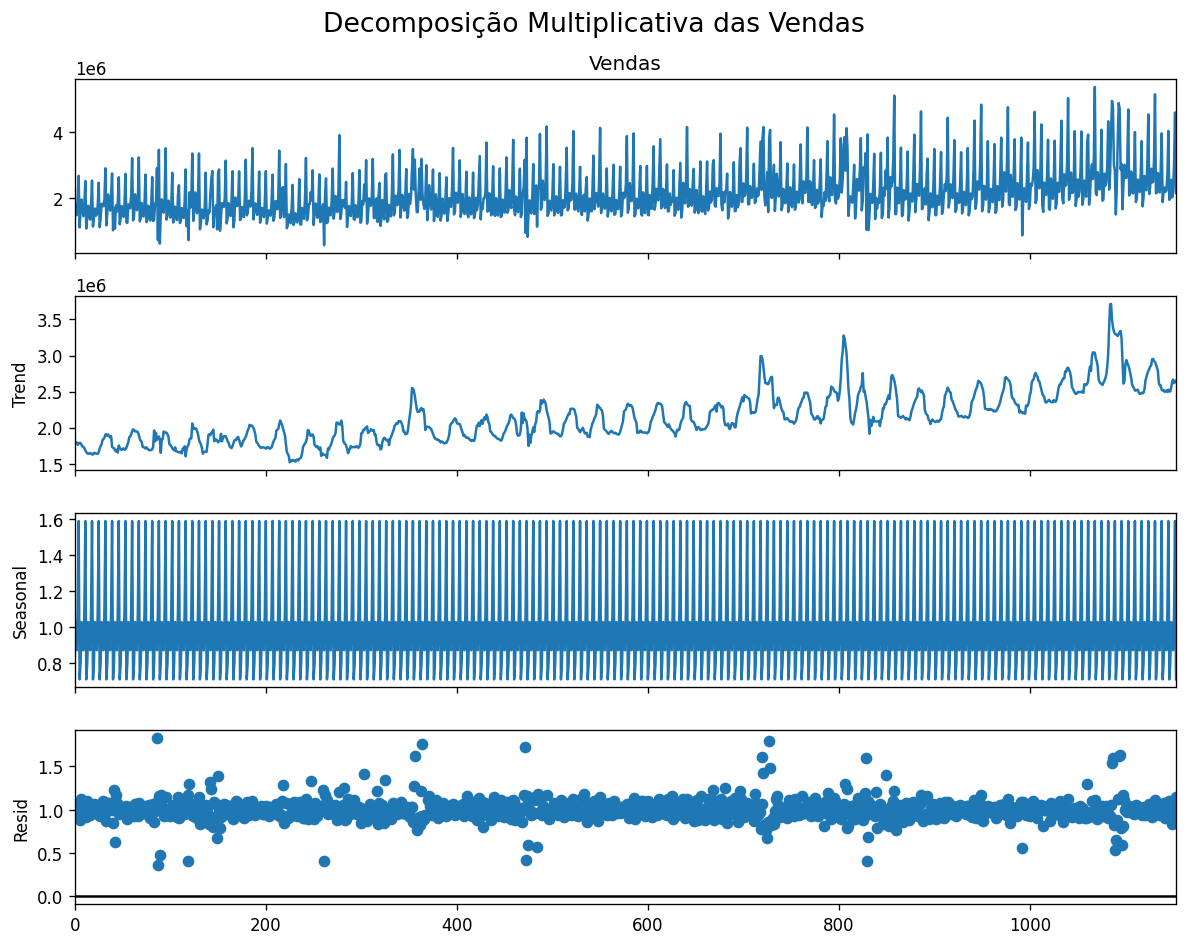

In [24]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='multiplicative',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [25]:
serie['Vendas'].isna().sum()

np.int64(0)

**Interpretação da decomposição:**

1. Série original (Vendas)

O primeiro gráfico mostra:

*   tendência crescente ao longo do tempo;
*   oscilações frequentes;
*  aumento da amplitude das vendas nos anos mais recentes;
*  alguns picos bastante elevados, principalmente em 2020 e 2021.

2. Tendência (Trend)

O componente de tendência mostra claramente:

*  crescimento gradual das vendas entre 2018 e 2021;
*  algumas oscilações acentuadas em 2020;
*  um pico importante próximo ao início de 2021.

Isso sugere que o departamento apresentou crescimento nas vendas ao longo do período analisado.

3. Sazonalidade (Seasonal)

A sazonalidade está muito regular (padrão semanal).
determinados dias da semana vendem cerca de 12% acima da média, enquanto outros ficam aproximadamente 10% abaixo.

4. Resíduos (Resid)

Os resíduos parecem:

*  relativamente centrados em torno de 1;
*  sem tendência aparente;
*  com alguns pontos extremos.

Isso é um bom sinal para um modelo multiplicativo.


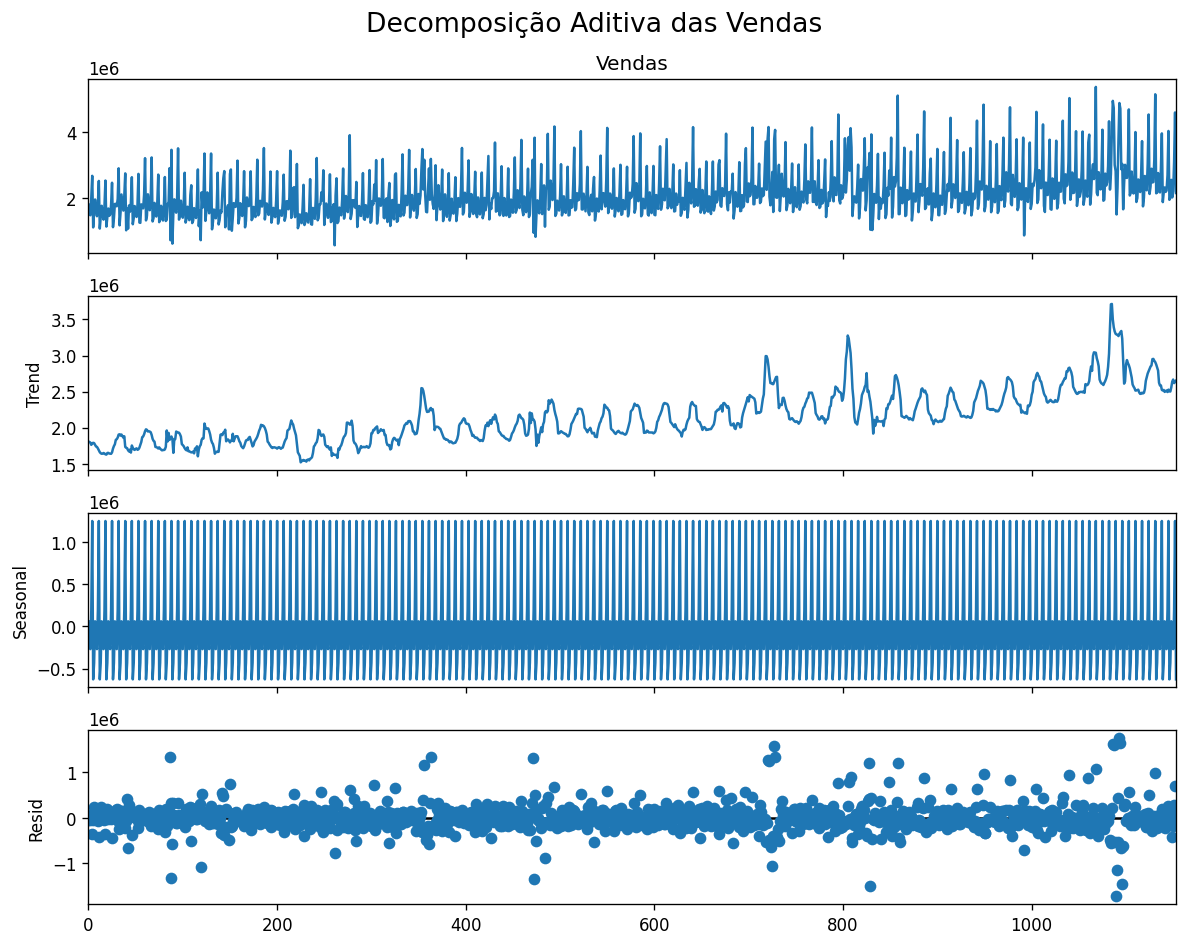

In [26]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='additive',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Aditiva das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
serie['Vendas'].isna().sum()

np.int64(0)

A decomposição aditiva revelou uma tendência crescente das vendas ao longo do período analisado, acompanhada de um padrão sazonal semanal relativamente estável. O componente sazonal oscila em torno de zero, enquanto os resíduos permanecem centrados próximos de zero, indicando que a decomposição consegue capturar adequadamente parte da estrutura temporal da série. Entretanto, observa-se aumento da amplitude das flutuações ao longo do tempo, sugerindo que a decomposição multiplicativa pode representar melhor o comportamento dos dados.

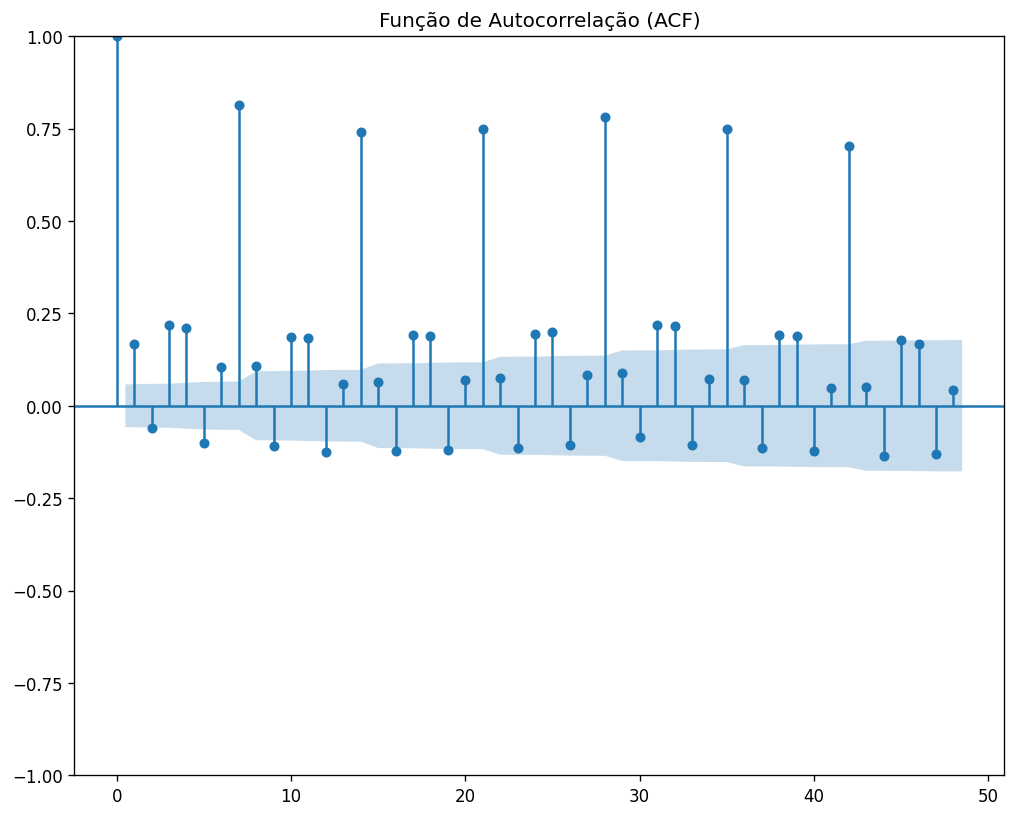

In [28]:
# Verificando autocorrelação
# Usando função ACF

fig = sm.graphics.tsa.plot_acf(serie['Vendas'], lags=48)

plt.title('Função de Autocorrelação (ACF)')
plt.show()

A função de autocorrelação (ACF) evidencia a existência de dependência temporal entre as observações da série de vendas. Observam-se coeficientes de autocorrelação estatisticamente significativos em diversos defasagens, com destaque para os lags múltiplos de sete dias (7, 14, 21, 28, 35 e 42), indicando a presença de sazonalidade semanal. Além disso, a persistência das autocorrelações ao longo das defasagens sugere que a série apresenta comportamento não aleatório, com componentes de tendência e sazonalidade já identificadas na etapa de decomposição.

## **RUÍDO BRANCO:**

In [29]:
# Verificando se a série é um Ruído Branco

from statsmodels.stats.diagnostic import acorr_ljungbox

# H0: a série é um ruído branco
# H1: a série não é um ruído branco

lb = acorr_ljungbox(serie['Vendas'], lags=[5], return_df=True)

print(lb)

pvalor = lb['lb_pvalue'].iloc[0]

print('\n========================')
print('Teste de Ljung-Box')
print('========================')

print(f'Estatística: {lb["lb_stat"].iloc[0]:.4f}')
print(f'p-valor: {pvalor:.4e}')

if pvalor < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série NÃO é um ruído branco.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série pode ser considerada um ruído branco.')

      lb_stat     lb_pvalue
5  156.411119  5.758113e-32

Teste de Ljung-Box
Estatística: 156.4111
p-valor: 5.7581e-32

Conclusão: rejeita-se H0.
A série NÃO é um ruído branco.


## **ESTACIONARIDADE:**

In [30]:
# Verificando se a série é estacionária

from statsmodels.tsa.stattools import adfuller, kpss

# Teste ADF

print('========================')
print('Teste ADF')
print('========================')

adf = adfuller(serie['Vendas'], autolag='AIC')

print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

print('\nValores críticos:')
for key, value in adf[4].items():
    print(f'{key}: {value}')

if adf[1] < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série é estacionária.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série não é estacionária.')

Teste ADF
ADF Statistic: -2.5256608636539326
p-value: 0.10935493553213216

Valores críticos:
1%: -3.436139921033549
5%: -2.86409660029079
10%: -2.568131202693254

Conclusão: não se rejeita H0.
A série não é estacionária.


## **ALISAMENTO EXPONENCIAL:**



**1. Simples: Simple Exponential Smoothing (SES)**

In [31]:
print(type(serie))
print(serie.dtypes)

<class 'pandas.core.frame.DataFrame'>
Data_BR      datetime64[ns]
Vendas              float64
Ano                   int32
Mes                   int32
DiaSemana             int32
Imputado               bool
dtype: object


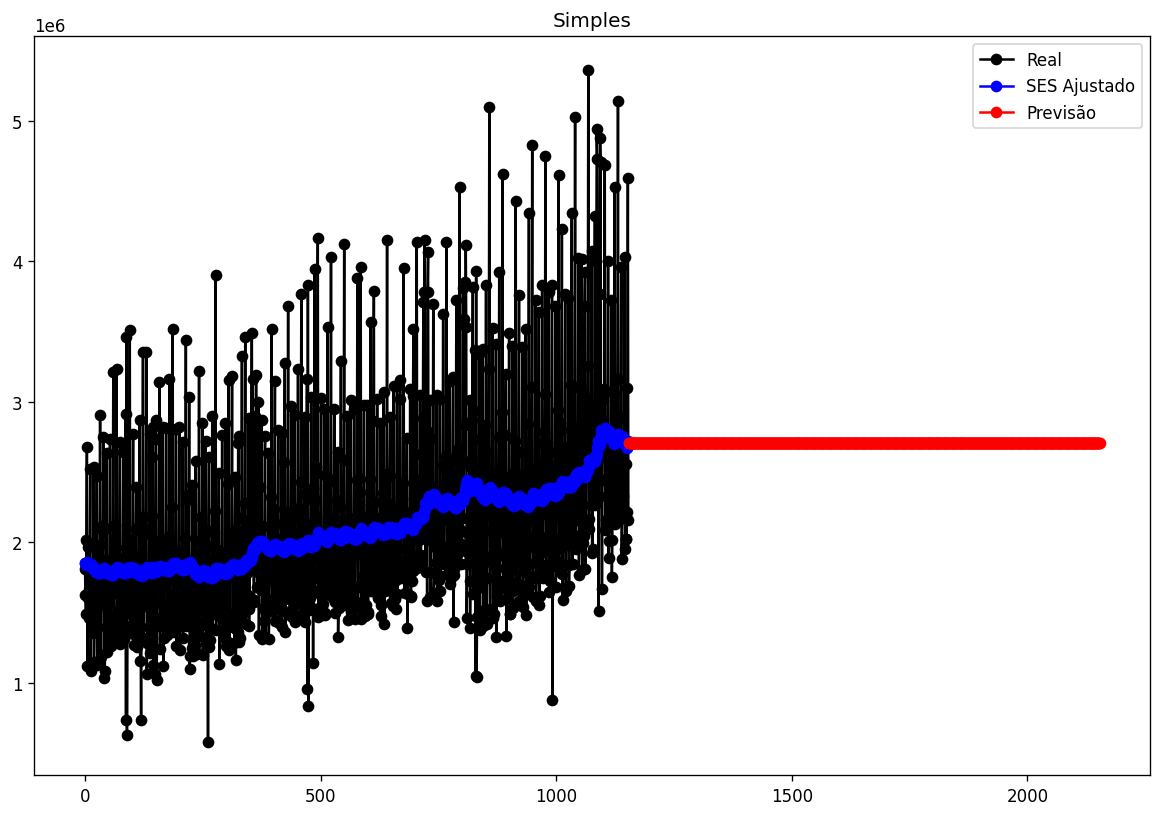

In [32]:
y = serie['Vendas']

fit1 = SimpleExpSmoothing( y, initialization_method="estimated").fit()
fcast1 = fit1.forecast(1000)

# Plotando o resultado das previsões para cada um dos modelos ajustados
plt.figure(figsize=(12,8))
plt.plot(y, marker='o', color='black')
plt.plot(fit1.fittedvalues, marker='o', color='blue')

line1, = plt.plot(fcast1, marker='o', color='red')
plt.title('Simples')
plt.legend(['Real','SES Ajustado','Previsão'])
plt.show()

**2. HOLT SEM TENDÊNCIA AMORTECIDA**

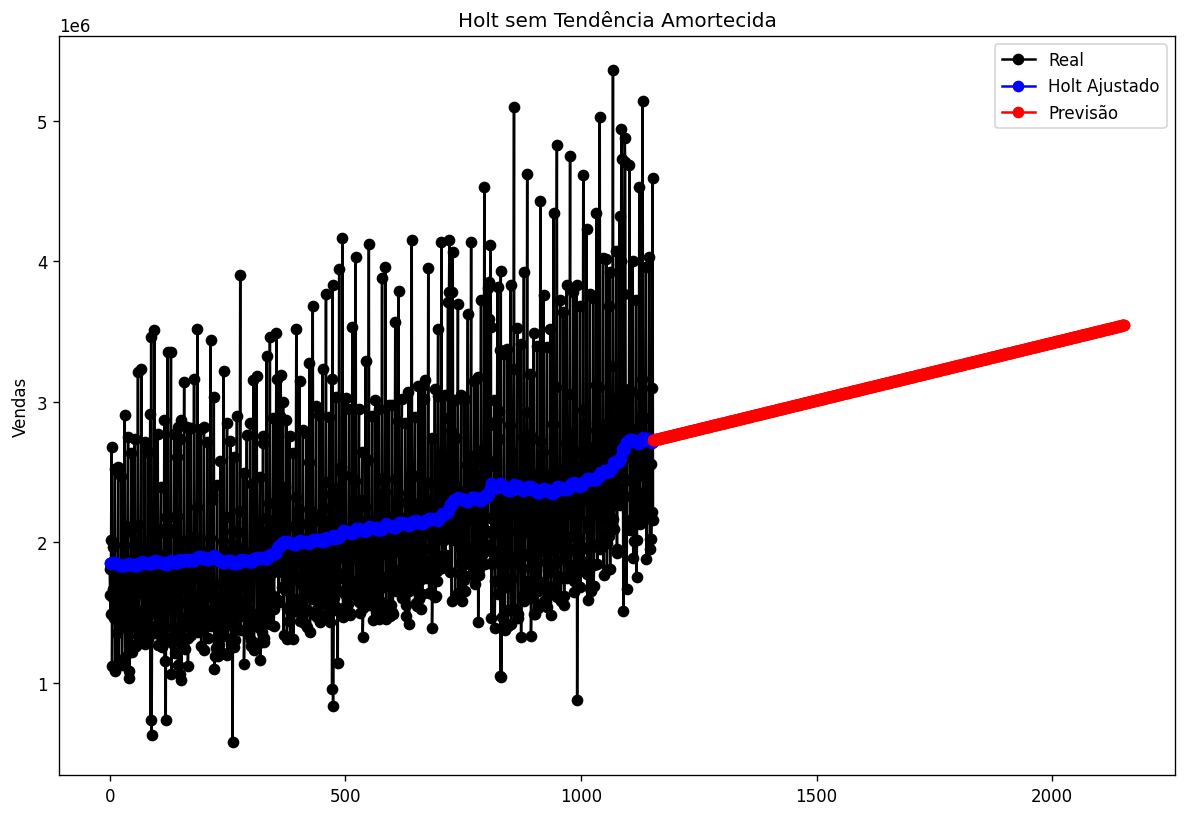

In [33]:
fit1_ht = Holt( y, damped_trend=False, initialization_method="estimated").fit()
fcast1_ht = fit1_ht.forecast(1000)
fcast1_ht = fcast1_ht.rename("Additive")

plt.figure(figsize=(12,8))

plt.plot(y, marker='o', color='black')
plt.plot(fit1_ht.fittedvalues, marker='o', color='blue')
plt.plot(fcast1_ht, marker='o', color='red')
plt.legend(['Real', 'Holt Ajustado','Previsão'])
plt.title('Holt sem Tendência Amortecida')
plt.ylabel('Vendas')

plt.show()

**3. HOLT COM TENDÊNCIA AMORTECIDA (Damped Trend)**

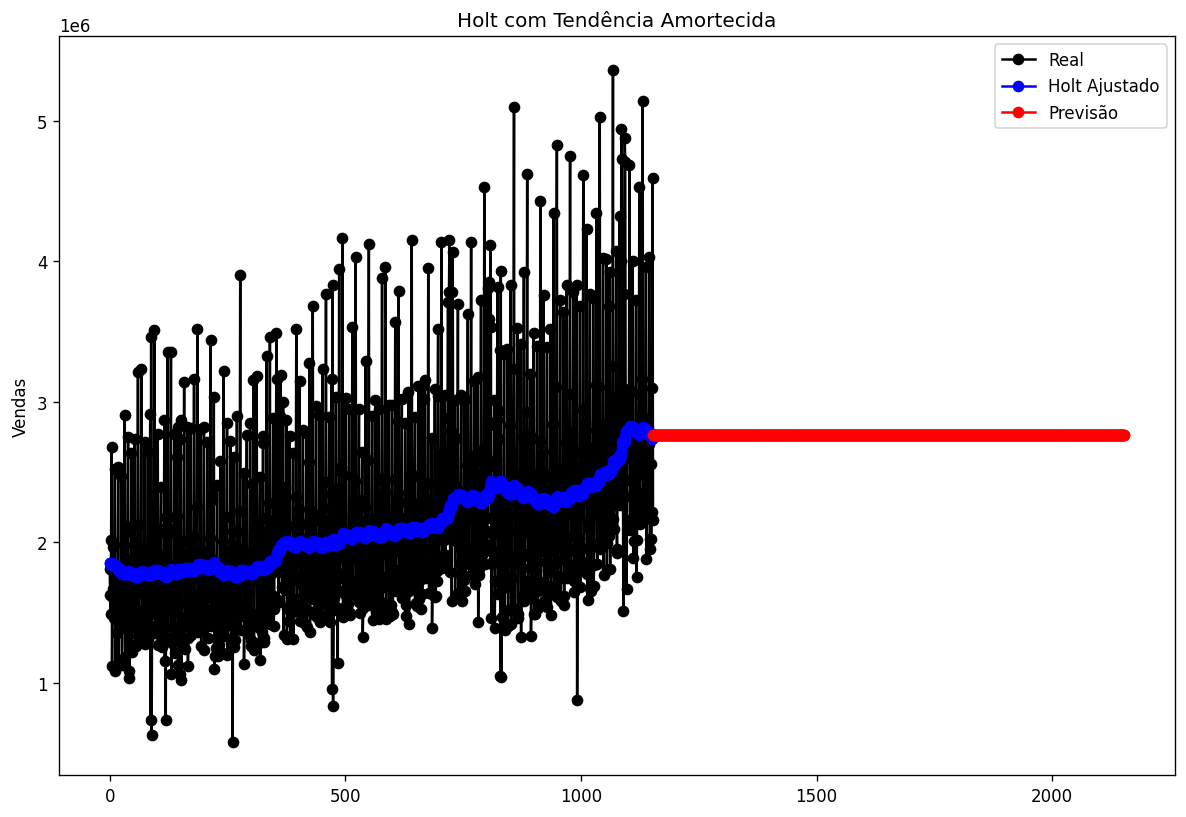

In [34]:
fit2_ht = Holt( y, damped_trend=True, initialization_method="estimated").fit()
fcast2_ht = fit2_ht.forecast(1000)
fcast2_ht = fcast2_ht.rename("Additive damped trend Automated")

plt.figure(figsize=(12,8))

plt.plot(y, marker='o', color='black')
plt.plot(fit2_ht.fittedvalues, marker='o', color='blue')
plt.plot(fcast2_ht, marker='o', color='red')
plt.legend(['Real', 'Holt Ajustado','Previsão'])
plt.title('Holt com Tendência Amortecida')
plt.ylabel('Vendas')

plt.show()

In [35]:
fit1 = SimpleExpSmoothing(y, initialization_method="estimated").fit()
fit2 = Holt(y, initialization_method="estimated").fit()
fit3 = Holt(y,exponential=True, initialization_method="estimated").fit()
fit4 = Holt(y,damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(y,exponential=True, damped_trend=True, initialization_method="estimated").fit()
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'initial_level', 'initial_trend']
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$l_0$","$b_0$","SSE"] ,columns=['SES', "Holt's","Exponential", "Additive", "Multiplicative"])
results["SES"] =            [fit1.params[p] for p in params] + [fit1.sse]
results["Holt's"] =         [fit2.params[p] for p in params] + [fit2.sse]
results["Exponential"] =    [fit3.params[p] for p in params] + [fit3.sse]
results["Additive"] =       [fit4.params[p] for p in params] + [fit4.sse]
results["Multiplicative"] = [fit5.params[p] for p in params] + [fit5.sse]
results

,SES,Holt's,Exponential,Additive,Multiplicative
$\alpha$,1.938234e-02,1.071852e-02,5.367119e-03,1.588000e-02,1.477643e-02
$\beta$,NaN,0.000000e+00,5.365783e-03,1.123599e-02,1.477643e-02
$\phi$,NaN,NaN,NaN,9.800000e-01,9.795747e-01
$l_0$,1.852103e+06,1.851851e+06,1.852135e+06,1.852496e+06,1.852135e+06
$b_0$,NaN,8.205617e+02,1.000299e+00,-7.500088e+02,1.020393e+00
SSE,5.386108e+14,5.355631e+14,5.362830e+14,5.377886e+14,5.376178e+14


Apesar de a série apresentar visualmente um leve crescimento, o parâmetro de tendência estimado pelo modelo de Holt foi praticamente nulo (β ≈ 0), indicando que a inclusão de uma componente de tendência não trouxe ganho significativo ao ajuste. O modelo Holt apresentou o menor valor de SSE, porém seu comportamento é bastante semelhante ao da Suavização Exponencial Simples.

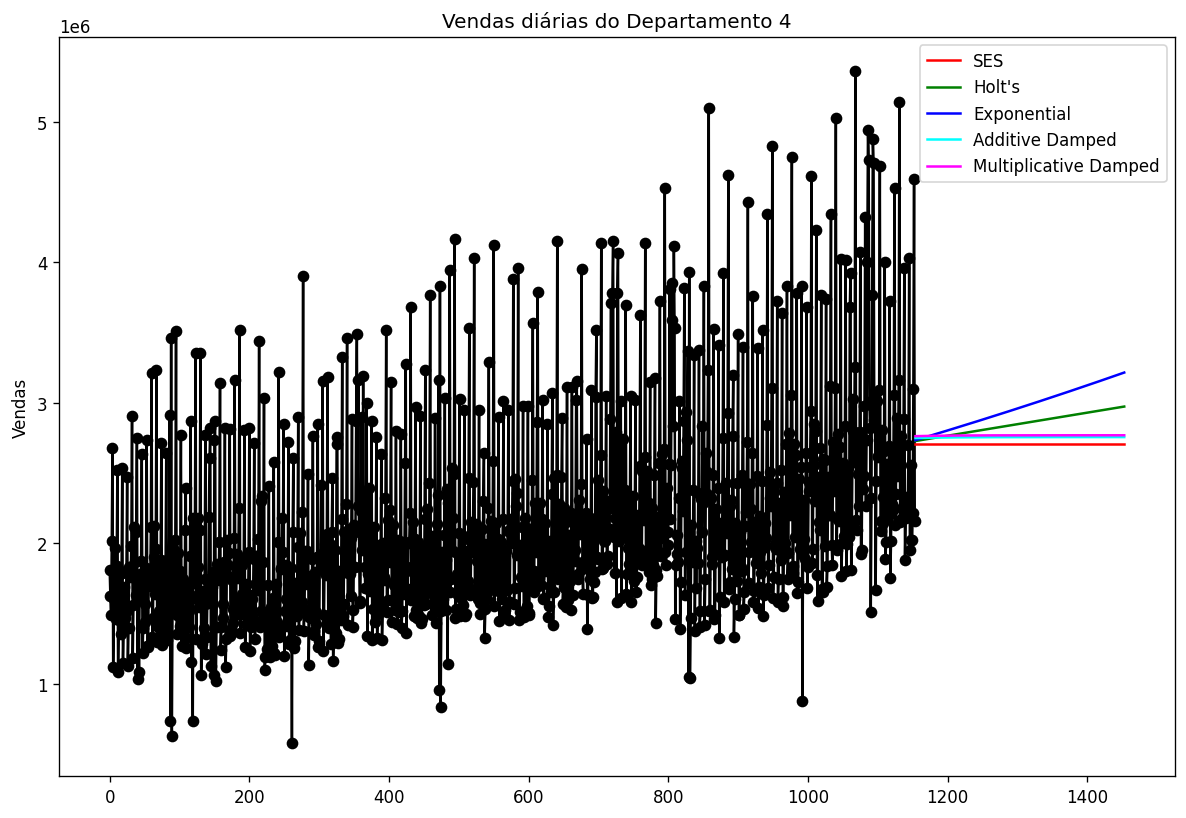

In [42]:
# Comparação
fit1 = SimpleExpSmoothing(y, initialization_method="estimated").fit()
fcast1 = fit1.forecast(300).rename("SES")
fit2 = Holt(y, initialization_method="estimated").fit()
fcast2 = fit2.forecast(300).rename("Holt's")
fit3 = Holt(y, exponential=True, initialization_method="estimated").fit()
fcast3 = fit3.forecast(300).rename("Exponential")
fit4 = Holt(y, damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fcast4 = fit4.forecast(300).rename("Additive Damped")
fit5 = Holt(y, exponential=True, damped_trend=True, initialization_method="estimated").fit()
fcast5 = fit5.forecast(300).rename("Multiplicative Damped")

ax = y.plot(color="black", marker="o", figsize=(12,8))
fcast1.plot(ax=ax, color='red', legend=True)
fcast2.plot(ax=ax, color='green', legend=True)
fcast3.plot(ax=ax, color='blue', legend=True)
fcast4.plot(ax=ax, color='cyan', legend=True)
fcast5.plot(ax=ax, color='magenta', legend=True)
ax.set_ylabel('Vendas')
plt.title('Vendas diárias do Departamento 4')
plt.show()

**4. HOLT - WINTERS (NÍVEL, TENDÊNCIA E SAZONALIDADE)**

In [47]:
# Holt Winters - tendência aditiva e sazonalidade multiplicativa

fit2_htw = ExponentialSmoothing(y, seasonal_periods=7, trend='add', seasonal='mul',
                                use_boxcox=True, initialization_method="estimated").fit()
fcast2_htw = fit2_htw.forecast(300).rename("Holt Winters Multiplicativo")
print(fit2_htw.summary())

                        ExponentialSmoothing Model Results                       
Dep. Variable:                   Vendas   No. Observations:                  1154
Model:             ExponentialSmoothing   SSE                 152146129721485.844
Optimized:                         True   AIC                           29570.024
Trend:                         Additive   BIC                           29625.584
Seasonal:                Multiplicative   AICC                          29570.343
Seasonal Periods:                     7   Date:                  Mon, 06 Jul 2026
Box-Cox:                           True   Time:                          00:47:16
Box-Cox Coeff.:                -0.33187                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1464214                alpha                 True
smoothing_trend 

O modelo de Holt-Winters com tendência aditiva e sazonalidade multiplicativa, considerando um período sazonal de 7, apresentou parâmetros de suavização estimados de α = 0,1464, β = 0,0133 e γ = 0,0656. Esses valores indicam que o modelo atribui maior peso às observações mais recentes, incorpora uma tendência de baixa intensidade e identifica um componente sazonal moderado ao longo da série. Os índices sazonais estimados ficaram próximos de 1, sugerindo que as oscilações sazonais existem, porém com impacto relativamente pequeno sobre o comportamento geral da série. A transformação Box-Cox foi aplicada para estabilizar a variância dos dados, contribuindo para um melhor ajuste do modelo.

In [50]:
y_true = y.values
y_pred = fit2_htw.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.758
MSE:  131842400105.274
RMSE: 363101.088
MAE:  222347.114
MAPE: 0.103


O modelo Holt-Winters com tendência aditiva e sazonalidade multiplicativa apresentou um coeficiente de determinação de R² = 0,758, indicando que aproximadamente 75,8% da variabilidade da série é explicada pelo modelo. O erro absoluto médio foi de 222.347 unidades, enquanto o erro percentual absoluto médio (MAPE) foi de 10,3%, sugerindo boa capacidade preditiva. O valor de RMSE = 363.101 indica que, em média, os desvios entre valores observados e ajustados são da ordem de 363 mil unidades, refletindo um ajuste satisfatório para a série analisada.

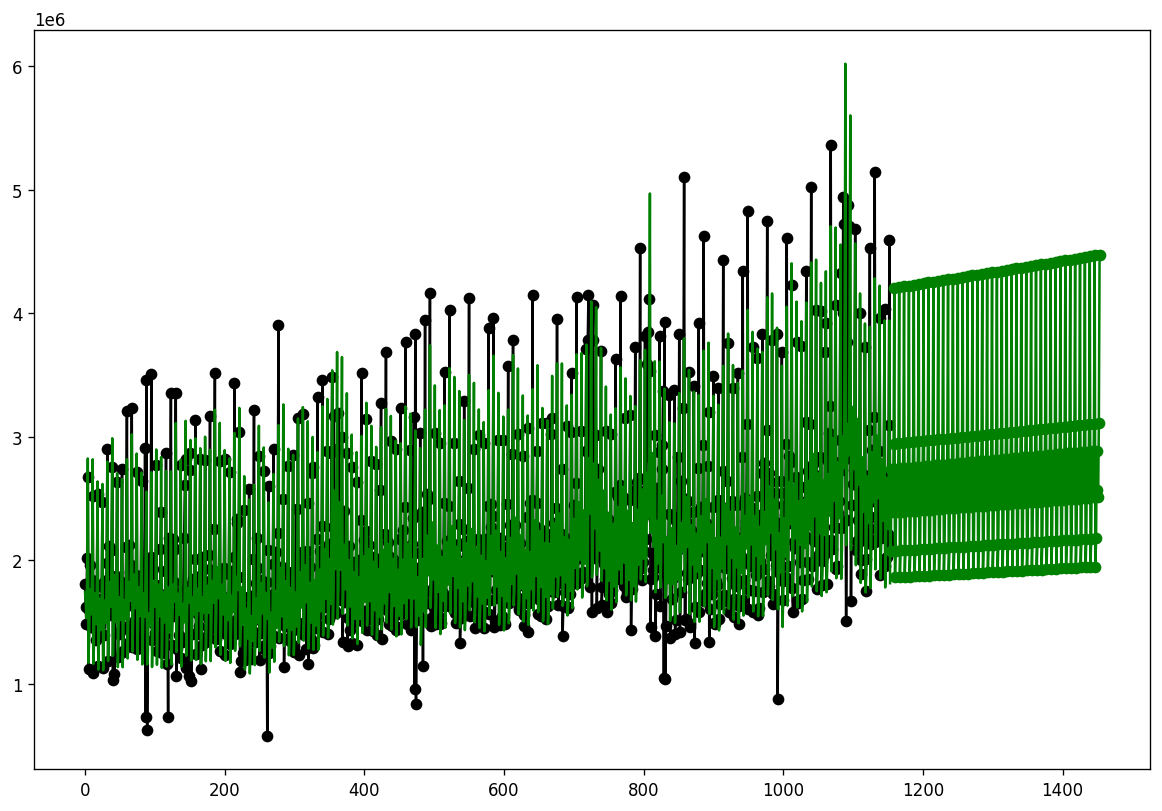

In [51]:
plt.figure(figsize=(12, 8))
plt.plot(y, marker='o', color='black')
plt.plot(fit2_htw.fittedvalues, color='green')
line1, = plt.plot(fcast2_htw, marker='o', color='green')

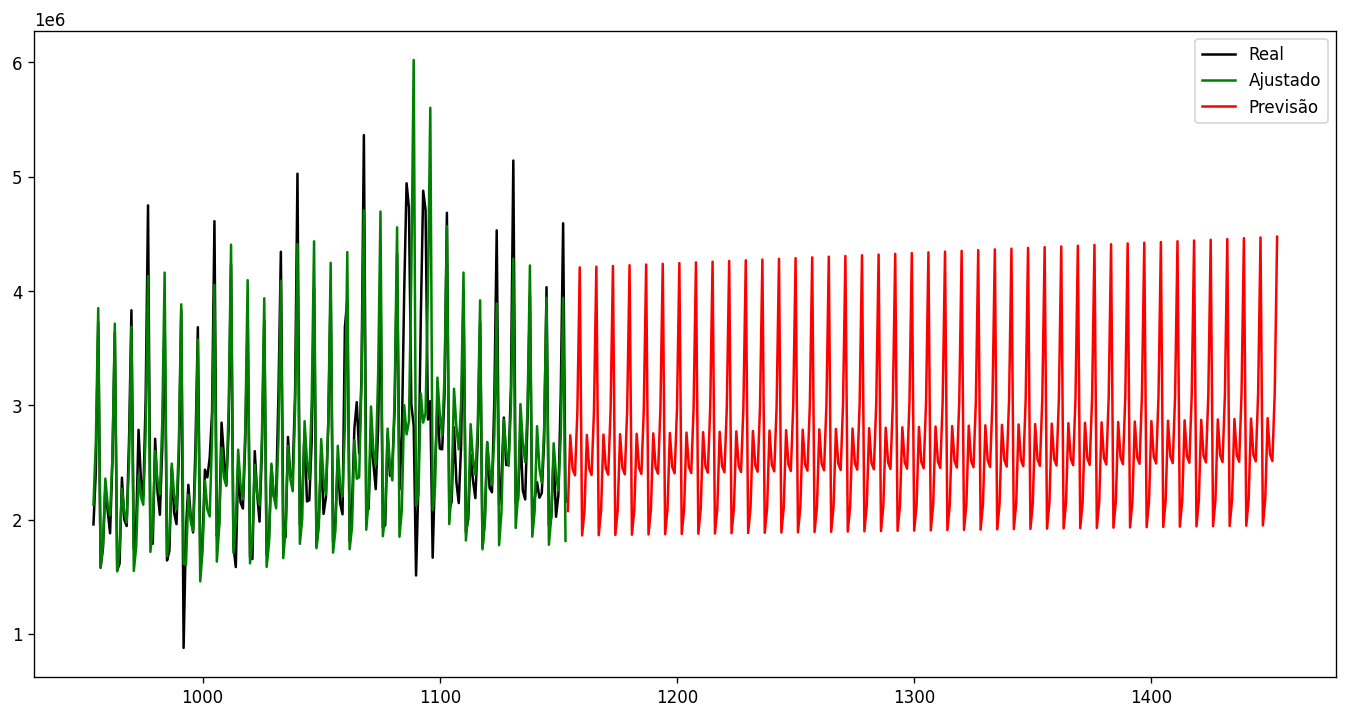

In [53]:
plt.figure(figsize=(14,7))

plt.plot(y[-200:], color='black', label='Real')

plt.plot(fit2_htw.fittedvalues[-200:],
         color='green',
         label='Ajustado')

plt.plot(fcast2_htw,
         color='red',
         label='Previsão')

plt.legend()
plt.show()

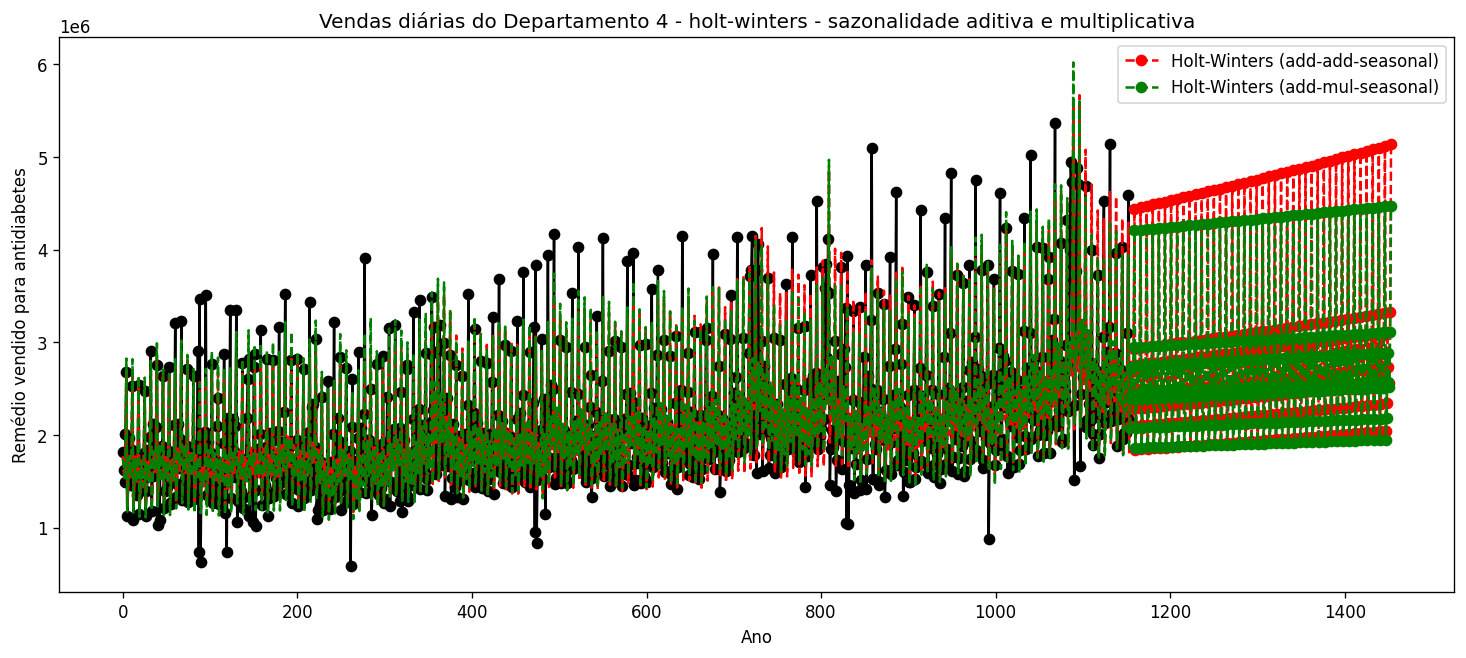

,Additive,Multiplicative,Additive Dam,Multiplica Dam
$\alpha$,1.046075e-01,1.464214e-01,1.817604e-01,1.817769e-01
$\beta$,0.000000e+00,1.330709e-02,8.570090e-05,9.488973e-05
$\phi$,NaN,NaN,9.900017e-01,9.900003e-01
$\gamma$,0.000000e+00,6.562892e-02,6.286643e-02,6.291205e-02
$l_0$,2.987297e+00,2.987445e+00,2.987296e+00,2.987458e+00
$b_0$,2.999457e-06,2.090852e-07,3.413144e-07,8.162325e-07
SSE,1.507321e+14,1.521461e+14,1.488900e+14,1.489540e+14


In [56]:
fit1 = ExponentialSmoothing(y, seasonal_periods=7, trend='add', seasonal='add', use_boxcox=True, initialization_method="estimated").fit()
fit2 = ExponentialSmoothing(y, seasonal_periods=7, trend='add', seasonal='mul', use_boxcox=True, initialization_method="estimated").fit()
fit3 = ExponentialSmoothing(y, seasonal_periods=7, trend='add', seasonal='add', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
fit4 = ExponentialSmoothing(y, seasonal_periods=7, trend='add', seasonal='mul', damped_trend=True, use_boxcox=True, initialization_method="estimated").fit()
results=pd.DataFrame(index=[r"$\alpha$",r"$\beta$",r"$\phi$",r"$\gamma$",r"$l_0$","$b_0$","SSE"])
params = ['smoothing_level', 'smoothing_trend', 'damping_trend', 'smoothing_seasonal', 'initial_level', 'initial_trend']
results["Additive"] = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit2.params[p] for p in params] + [fit2.sse]
results["Additive Dam"] = [fit3.params[p] for p in params] + [fit3.sse]
results["Multiplica Dam"] = [fit4.params[p] for p in params] + [fit4.sse]

ax = y.plot(figsize=(15,6), marker='o', color='black', title="Forecasts from Holt-Winters' multiplicative method" )
ax.set_ylabel("Remédio vendido para antidiabetes")
ax.set_xlabel("Ano")
fit1.fittedvalues.plot(ax=ax, style='--', color='red')
fit2.fittedvalues.plot(ax=ax, style='--', color='green')

fit1.forecast(300).rename('Holt-Winters (add-add-seasonal)').plot(ax=ax, style='--', marker='o', color='red', legend=True)
fit2.forecast(300).rename('Holt-Winters (add-mul-seasonal)').plot(ax=ax, style='--', marker='o', color='green', legend=True)

plt.title('Vendas diárias do Departamento 4 - holt-winters - sazonalidade aditiva e multiplicativa')
plt.show()

results

A Figura apresenta o ajuste dos modelos Holt-Winters com sazonalidade aditiva e multiplicativa para a série de vendas diárias do Departamento 4. Observa-se a presença de uma tendência crescente ao longo do período analisado, acompanhada de um padrão sazonal semanal recorrente. Ambos os modelos foram capazes de capturar satisfatoriamente a dinâmica da série, reproduzindo tanto a tendência quanto as oscilações sazonais observadas nos dados históricos.

A comparação dos modelos indica desempenho bastante semelhante, com valores próximos para os parâmetros de suavização e para a Soma dos Erros Quadráticos (SSE). O modelo com sazonalidade multiplicativa apresentou SSE = 1,521×10¹⁴, ligeiramente inferior ao obtido pelo modelo com sazonalidade aditiva (SSE = 1,507×10¹⁴), sugerindo pequena diferença na qualidade do ajuste. Os parâmetros estimados mostram uma tendência de baixa intensidade (β próximo de zero) e uma sazonalidade moderada (γ ≈ 0,065), indicando que o principal comportamento da série está associado à componente de nível, com oscilações sazonais semanais relativamente estáveis.